In [1]:
import json
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from regex import F
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
import re

In [2]:
def fill_missing_nearest(film_dict, categories):
    df = pd.DataFrame({cat: film_dict[cat] for cat in categories}, dtype=float)
    df = df.fillna(method="ffill").fillna(method="bfill")
    return df

def compute_similarity_matrix_from_ratings(rating_df):
    return rating_df.corr(method='pearson')

def run_mds_across_films(rating_data, movie_names_to_remove, out_json=None):
    movie_names = [m for m in rating_data.keys() if m not in movie_names_to_remove]
    #print('Running MDS across films: ', movie_names)

    rating_similarity_matrix = compute_similarity_matrix_from_ratings(pd.concat([pd.DataFrame(rating_data[movie]) for movie in movie_names])) 
    #print('Computing MDS on similarity matrix:', rating_similarity_matrix.head())
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=121, metric=True)
    mds_coords = mds.fit_transform(1 - rating_similarity_matrix)  # n_cat × 2
    #print('MDS coordinates:', mds_coords)


    # Fill missing values 
    filled_dfs = []
    for movie in movie_names:
        categories = list(rating_data[movie].keys())
        df = fill_missing_nearest(rating_data[movie], categories)
        #print('Filled DataFrame for movie:', movie, df.head())
        filled_dfs.append(df)

    # Project each film separately
    transformed = {}
    for movie, df in zip(movie_names, filled_dfs):
        ratings_array = df.values  # T × n_cat
        time_series = ratings_array @ mds_coords  # T × 2
        transformed[movie] = {"mds1": time_series[:, 0].tolist(),"mds2": time_series[:, 1].tolist()}

    if out_json is not None:
        with open(out_json, 'w') as f:
            json.dump(transformed, f, indent=2)

    return transformed, mds_coords


def rescale_to_match(traj, ref_coords, preserve_aspect=True):
    #Linearly rescale trajectory into the coordinate range of reference coords.

    # reference bounds
    x_min, x_max = ref_coords[:, 0].min(), ref_coords[:, 0].max()
    y_min, y_max = ref_coords[:, 1].min(), ref_coords[:, 1].max()
    
    if preserve_aspect:
        # scale uniformly across both axes
        ref_min = np.array([x_min, y_min])
        ref_max = np.array([x_max, y_max])
        
        traj_min = traj.min(axis=0)
        traj_max = traj.max(axis=0)
        
        # choose the same scaling factor for both axes
        scale_ref = (ref_max - ref_min).max()
        scale_traj = (traj_max - traj_min).max()
        
        traj_scaled = (traj - traj_min) / scale_traj * scale_ref + ref_min
    else:
        # rescale per axis independently
        traj_scaled = np.empty_like(traj)
        traj_scaled[:, 0] = np.interp(traj[:, 0],(traj[:, 0].min(), traj[:, 0].max()),(x_min, x_max))
        traj_scaled[:, 1] = np.interp(traj[:, 1],(traj[:, 1].min(), traj[:, 1].max()),(y_min, y_max))
    
    return traj_scaled


def mds_plot_wtraj(similarity_matrix, mds_coords, categories, rating_data, film_data=None, film_name=None, grid_size=11, title=None, save=None, fontsize=25, plot_grid=False,ax=None,figsize=(15, 15),linewidth=2):
    #Plot MDS category positions and optionally overlay a film's trajectory.

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    plt.rcParams.update({'font.size': fontsize})
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams['font.sans-serif'] = ['Arial']

    # plot MDS category positions 
    ax.scatter(mds_coords[:, 0], mds_coords[:, 1], s=800, c='orange', linewidth=2)
    for i, txt in enumerate(similarity_matrix.columns):
        offset_x = -0.2 if txt == 'Happiness' else -0.3 if txt == 'Disgust' else -0.2 if txt in ['Anxiety','Anger'] else 0
        ax.annotate(txt, (mds_coords[i, 0] + offset_x, mds_coords[i, 1]),fontsize=fontsize, weight='bold')

    # plot film trajectory 
    if film_data is not None:
        traj_raw = np.vstack([film_data["mds1"], film_data["mds2"]]).T  # T * 2
        traj_plot = rescale_to_match(traj_raw, mds_coords, preserve_aspect=True) 

        ax.plot(traj_plot[:, 0], traj_plot[:, 1], color='#1f77b4', linewidth=3, alpha=0.7)
        ax.scatter(traj_plot[:, 0], traj_plot[:, 1], c='blue', s=np.linspace(2, 10, len(traj_plot))*10, alpha=0.6)
        #ax.scatter(traj_plot[:, 0], traj_plot[:, 1], c=np.linspace(0, 1, len(traj_plot)),cmap='Blues', s=40, alpha=0.6)

    # set grid 
    if plot_grid:
        x_min, x_max = mds_coords[:, 0].min(), mds_coords[:, 0].max()
        y_min, y_max = mds_coords[:, 1].min(), mds_coords[:, 1].max()
        ax.set_xticks(np.linspace(x_min, x_max, grid_size))
        ax.set_yticks(np.linspace(y_min, y_max, grid_size))
        ax.tick_params(axis='both', which='both', bottom=False, top=False,left=False, right=False, labelbottom=False, labelleft=False)
        for side in ['top','right','left','bottom']:
            plt.gca().spines[side].set_visible(False)
        plt.grid(True, which='both', linestyle='-', linewidth=2, color='gray', alpha=0.5)
    else:
        #add axis labels, (mds 1 and mds 2)
        #ax.set_xlabel('MDS 1', fontsize=fontsize)
        #ax.set_ylabel('MDS 2', fontsize=fontsize)
        #remove tick labels
        ax.tick_params(axis='both', which='both', bottom=False, top=False,left=False, right=False, labelbottom=False, labelleft=False)
        ax.set_xticks([])
        ax.set_yticks([])
        #remove grid
        ax.grid(False)
        #remove top and right spines
        #ax.spines['top'].set_visible(False)
        #ax.spines['right'].set_visible(False)
        #ax.spines['left'].set_visible(False)
        #ax.spines['bottom'].set_visible(False)
        #make the remaining spines thicker
        #ax.spines['left'].set_linewidth(linewidth)
        #ax.spines['bottom'].set_linewidth(linewidth)

    # title 
    if title:
        ax.set_title(title, fontsize=25, pad=20)
    elif film_name:
        film_name_separated = re.sub(r'(?=[A-Z])', ' ', film_name)
        ax.set_title(film_name_separated, fontsize=25, pad=20)

    if save:
        plt.savefig(save, dpi=600)
    if ax is None:
        plt.show()

In [ ]:
rating_data = json.load(open('./data/behTab_json.json'))
movie_names_to_remove = ['DamagedKungFu', 'RidingTheRails','LeassonLearned']
transformed_mds, mds_coords = run_mds_across_films(rating_data, movie_names_to_remove)#, "./outputs/mds_2d.json")

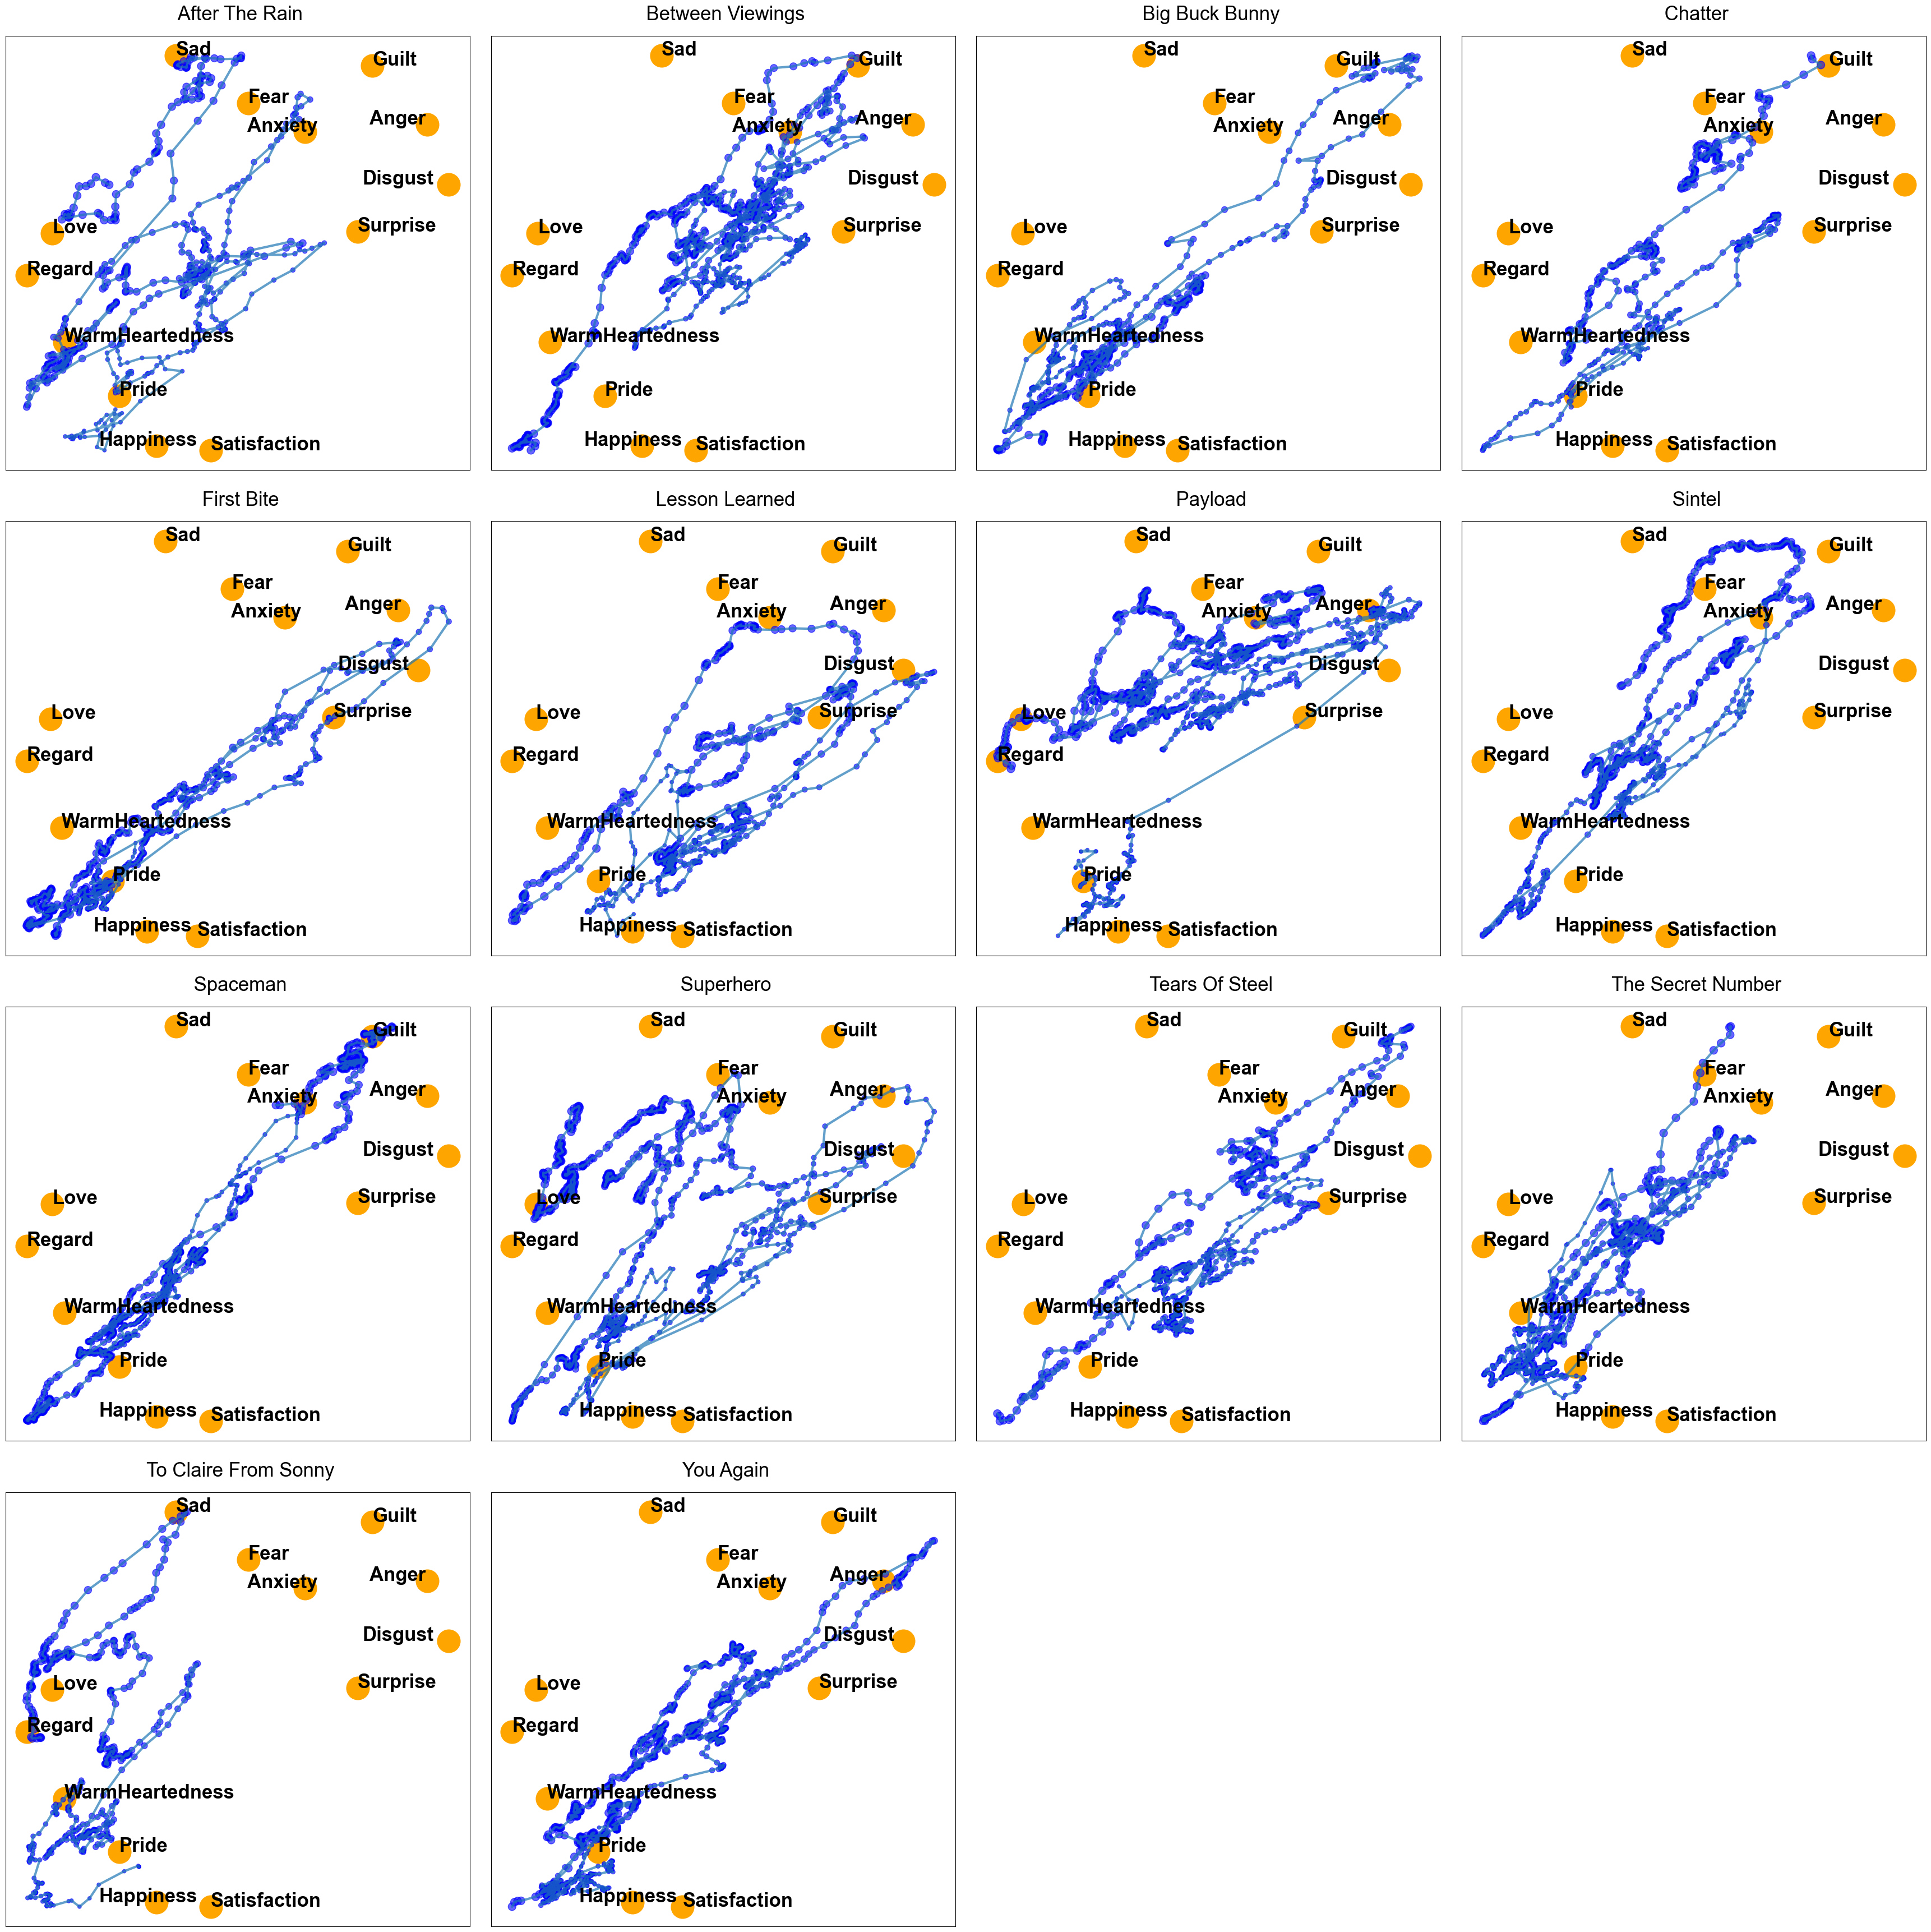

In [4]:
rating_data = json.load(open('./data/behTab_json.json'))
movie_names = list(rating_data.keys())
movie_names_to_remove = ['DamagedKungFu', 'RidingTheRails','LeassonLearned']
movie_names = [movie for movie in movie_names if movie not in movie_names_to_remove]  
categories = ['Anger', 'Anxiety', 'Fear', 'Surprise', 'Guilt', 'Disgust', 'Sad','Regard', 'Satisfaction', 'WarmHeartedness', 'Happiness', 'Pride','Love']
rating_similarity_matrix = compute_similarity_matrix_from_ratings(pd.concat([pd.DataFrame(rating_data[movie]) for movie in movie_names]))
#create subplots based on how many movies are in the list (each row can have 4 movies, so calculate the number of rows)
num_rows = len(movie_names) // 4 + (1 if len(movie_names) % 4 != 0 else 0)
fig, axs = plt.subplots(num_rows, 4, figsize=(35, 35))
for i, movie_name in enumerate(movie_names):
    mds_plot_wtraj(rating_similarity_matrix, mds_coords, categories, rating_data, film_data=transformed_mds[movie_name],film_name=movie_name, ax=axs[i//4, i%4], figsize=(20, 20))
    #turn off the x axis except for the last row, and the y axis except for the first column
    if i//4 != num_rows-1:
        axs[i//4, i%4].set_xlabel('')
    if i%4 != 0:
        axs[i//4, i%4].set_ylabel('')
    #turn on 10 and 11's x axis
    if i == 10 or i == 11:
        #axs[i//4, i%4].set_xlabel('MDS 1')
        axs[i//4, i%4].set_xlabel('')

#remove the axis for locations without a film 
for i in range(num_rows*4):
    if i >= len(movie_names):
        axs[i//4, i%4].remove()
plt.tight_layout()
#plt.savefig('./outputs/MDStrajs_allfilms.jpeg', dpi=600)
plt.show()

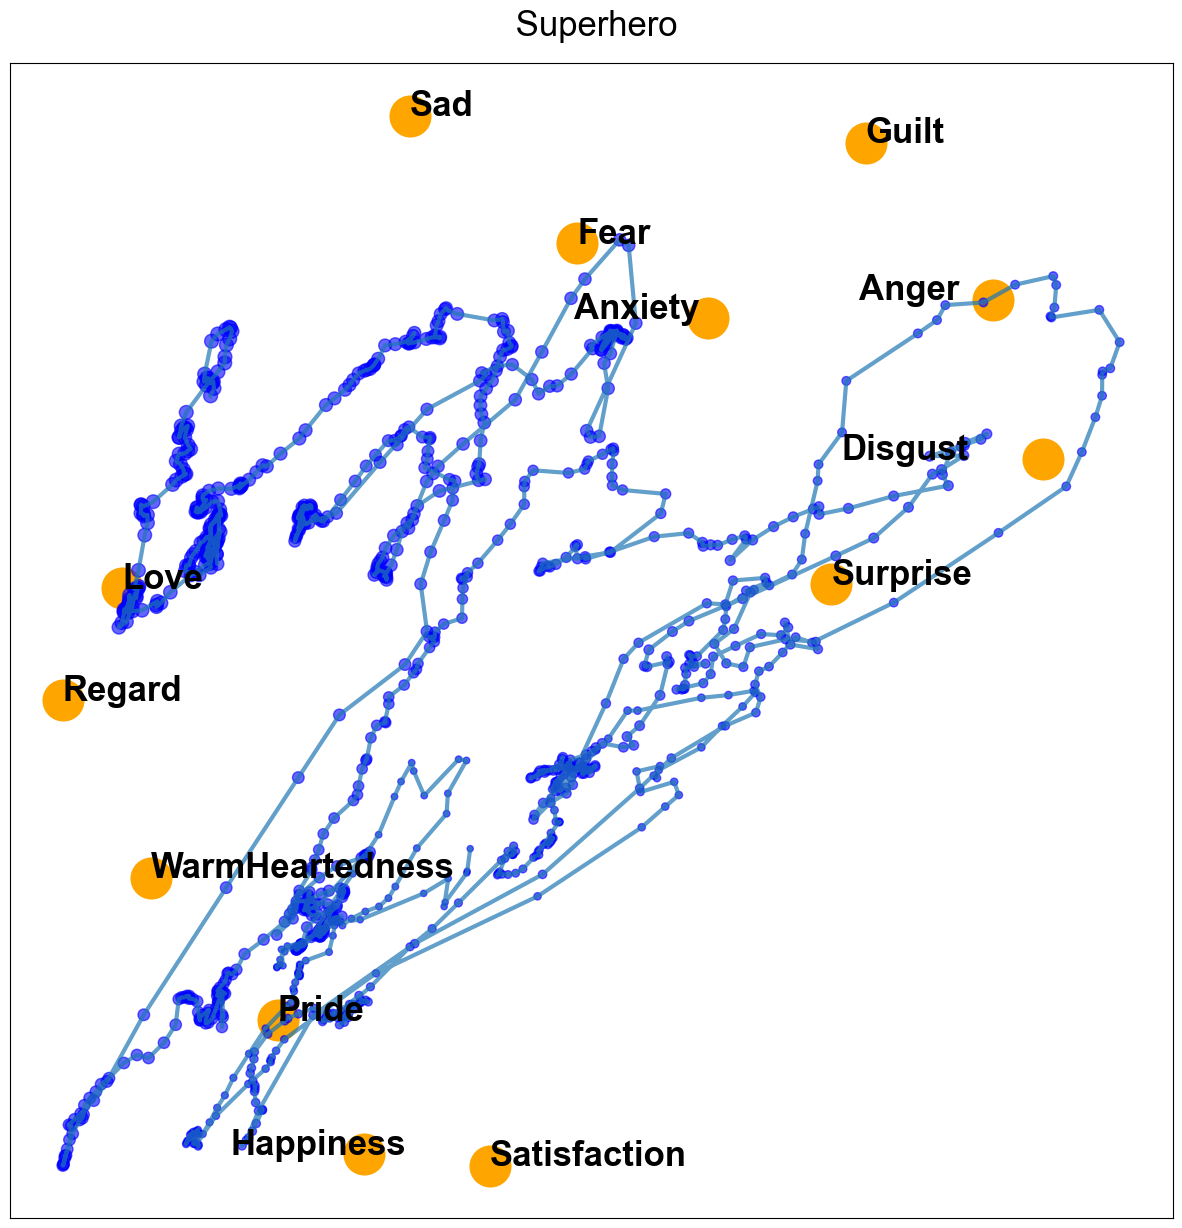

In [5]:
save_path = './outputs/MDStrajs_Superhero.jpeg'
mds_plot_wtraj(rating_similarity_matrix, mds_coords, categories, rating_data, film_data=transformed_mds['Superhero'],film_name='Superhero', ax=None, figsize=(15, 15), linewidth=2.3)#,save=save_path)
#save_path = './outputs/MDStrajs_wGrid_Superhero.jpeg'
#mds_plot_wtraj(rating_similarity_matrix, mds_coords, categories, rating_data, film_data=transformed_mds['Superhero'],film_name='Superhero', ax=None, figsize=(15, 15), save=save_path,linewidth=2.3, plot_grid=True)